# 01 - FFT Analysis: Espectro y Ciclos Dominantes

Este notebook muestra cómo calcular la Transformada Rápida de Fourier (FFT) sobre precios de cierre, visualizar el espectro de potencias, identificar ciclos dominantes y reconstruir una señal filtrada que retenga solo las frecuencias seleccionadas.

## 1. Setup e importaciones

In [6]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from curso.lib.data import download_historical, interpolate_gaps

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup completado ✓')

Setup completado ✓


## 2. Parámetros

In [2]:
# Parámetros configurables
TICKER = "AAPL"
LOOKBACK_YEARS = 5
FFT_TOP_N = 2           # Número de ciclos dominantes a retener
MIN_PERIOD = 10         # Periodo mínimo en días para considerar un ciclo
MAX_PERIOD = 80         # Periodo máximo en días para considerar un ciclo
PAD_TO_POWER_OF_2 = True

print('Parámetros:', TICKER, LOOKBACK_YEARS, FFT_TOP_N, MIN_PERIOD, MAX_PERIOD)

Parámetros: AAPL 5 2 10 80


## 3. Descargar y preprocesar datos

In [3]:
# Descargar datos (la función download_historical usa 5 años por defecto si start_date=None)
df = download_historical(TICKER, start_date=None, end_date=None)

# Asegurar columna Close y ordenar por fecha
if 'Close' not in df.columns:
    raise ValueError('No se encontró la columna Close en los datos descargados')

df = df.sort_index()

# Interpolar gaps si existen
try:
    df = interpolate_gaps(df)
except Exception:
    # Fallback: simple linear interpolation if helper falla
    df = df.interpolate(method='linear').ffill().bfill()

close = df['Close'].astype(float).dropna()
N = len(close)
print(f'Datos: {TICKER} → {N} registros (desde {close.index[0].date()} hasta {close.index[-1].date()})')

Datos: AAPL → 1255 registros (desde 2021-06-02 hasta 2026-06-01)


## 4. FFT y espectro de potencias

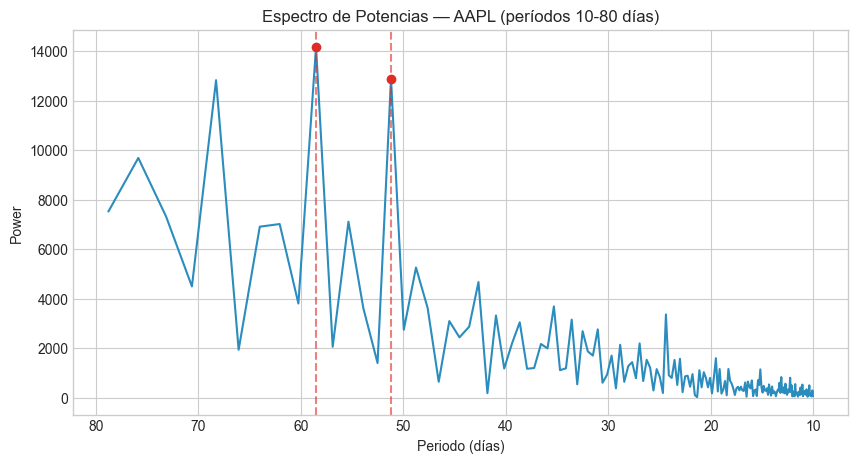

,rank,period_days,frequency,power,fft_index
0,1,58.51,0.017090,14164.208475,35
1,2,51.20,0.019531,12893.325788,40


In [4]:
# Preparar array y padding a potencia de 2 (opcional)
orig_n = N
if PAD_TO_POWER_OF_2:
    next_pow2 = 1 << (N - 1).bit_length()
    pad_n = next_pow2 if next_pow2 >= N else N
else:
    pad_n = N

close_vals = close.values
if pad_n > N:
    close_padded = np.concatenate([close_vals, np.zeros(pad_n - N)])
else:
    close_padded = close_vals.copy()

# Real FFT
fft_coeffs = np.fft.rfft(close_padded)
power = (np.abs(fft_coeffs) ** 2) / len(close_padded)
freqs = np.fft.rfftfreq(len(close_padded), d=1.0)  # ciclos por día

# Periodo en días (evitar división por cero)
periods_days = np.full_like(freqs, np.nan, dtype=float)
nonzero = freqs > 0
periods_days[nonzero] = 1.0 / freqs[nonzero]

# Filtrar por rango de periodos de interés
valid_idx = np.where((periods_days >= MIN_PERIOD) & (periods_days <= MAX_PERIOD))[0]
if len(valid_idx) == 0:
    raise ValueError('No hay frecuencias en el rango de periodos seleccionado')

# Seleccionar top-N por potencia dentro del rango
sorted_idx = valid_idx[np.argsort(power[valid_idx])[::-1]]
top_idx = sorted_idx[:FFT_TOP_N]

# Tabla con ciclos dominantes
cycles = []
for rank, idx in enumerate(top_idx, start=1):
    cycles.append({
        'rank': rank,
        'period_days': float(np.round(periods_days[idx], 2)),
        'frequency': float(np.round(freqs[idx], 6)),
        'power': float(np.round(power[idx], 6)),
        'fft_index': int(idx),
    })

cycles_df = pd.DataFrame(cycles)

# Plot power spectrum (periods en eje X)
plt.figure(figsize=(10, 5))
# Plot only valid range for clarity
mask = (periods_days >= MIN_PERIOD) & (periods_days <= MAX_PERIOD)
plt.plot(periods_days[mask], power[mask], color='#2b8cbe')
plt.scatter(cycles_df['period_days'], cycles_df['power'], color='#de2d26', zorder=5)
for _, row in cycles_df.iterrows():
    plt.axvline(row['period_days'], color='#de2d26', linestyle='--', alpha=0.6)

plt.xlabel('Periodo (días)')
plt.ylabel('Power')
plt.title(f'Espectro de Potencias — {TICKER} (períodos {MIN_PERIOD}-{MAX_PERIOD} días)')
plt.gca().invert_xaxis()  # mostrar ciclos cortos a la derecha opcional
plt.grid(True)
plt.show()

cycles_df

## 5. Reconstrucción de señal filtrada (mantener top N frecuencias)

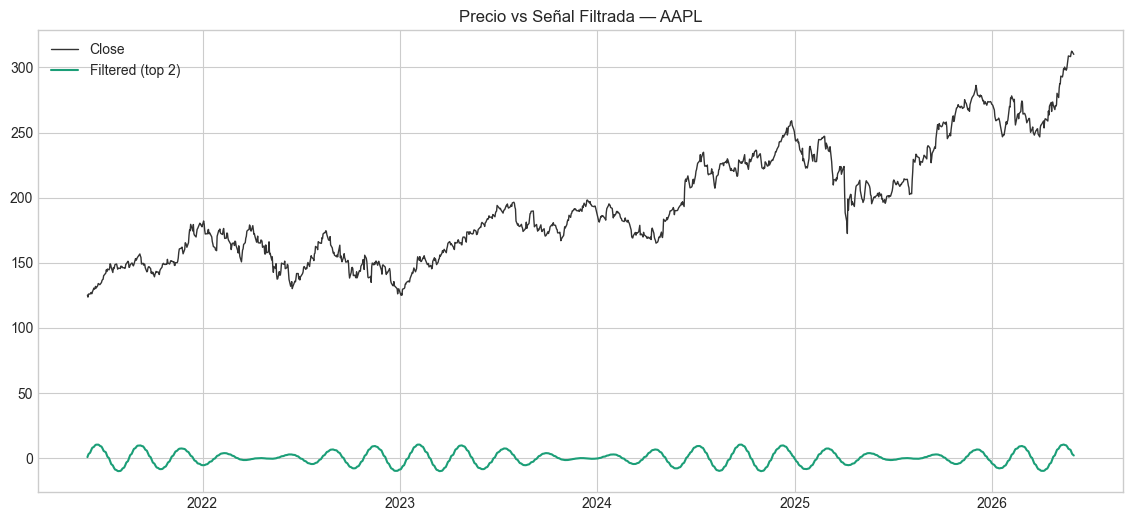

In [5]:
# Construir FFT filtrada: conservar solo los coeficientes en top_idx
fft_filtered = np.zeros_like(fft_coeffs, dtype=complex)
for idx in top_idx:
    fft_filtered[idx] = fft_coeffs[idx]

# Inversa (usar el tamaño padded)
filtered_padded = np.fft.irfft(fft_filtered, n=len(close_padded))
# Recortar a longitud original
filtered_signal = filtered_padded[:orig_n]

# Construir DataFrame de salida para graficar
out_df = pd.DataFrame({'Close': close.values, 'Filtered': filtered_signal}, index=close.index)

# Plot precio original vs señal filtrada
plt.figure(figsize=(14, 6))
plt.plot(out_df.index, out_df['Close'], label='Close', color='#333333', linewidth=1)
plt.plot(out_df.index, out_df['Filtered'], label=f'Filtered (top {FFT_TOP_N})', color='#1b9e77', linewidth=1.5)
plt.legend()
plt.title(f'Precio vs Señal Filtrada — {TICKER}')
plt.show()

## 6. Interpretación y limitaciones

- La señal filtrada muestra las oscilaciones asociadas a los ciclos retenidos.  
- Recalcular la FFT periódicamente (p. ej. cada 30-60 días) es recomendable porque los ciclos pueden cambiar con el tiempo.  
- Evitar interpretar picos débiles como ciclos robustos — usar criterios de prominencia/consistencia.  
- La FFT asume cierta estacionariedad; para series no estacionarias considere ventanas móviles o transformadas tipo STFT/WT.

---

Puedes reutilizar la lógica de identificación y filtrado en el notebook de estrategia para generar señales de trading y backtests.